Heart Failure Prediction

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Data Science (1)/Heart Failure Prediction/heart_failure_clinical_records_dataset.csv', sep=';')

In [8]:
import pandas as pd

path = '/content/drive/MyDrive/Data Science (1)/Heart Failure Prediction/heart_failure_clinical_records_dataset.csv'

# Step 1: read with semicolon separator
df = pd.read_csv(path, sep=';')

# Step 2: clean column names (strip spaces)
df.columns = df.columns.str.strip()

# Step 3: strip whitespace from all string/object values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

# Step 4: replace '-' (used as a stand-in for 0) with 0
df = df.replace('-', 0)

# Step 5: replace comma decimals with dot decimals, e.g. '1,00' -> '1.00'
for col in df.columns:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)

# Step 6: convert everything to numeric, forcing bad values to NaN
df = df.apply(pd.to_numeric, errors='coerce')

# Step 7: check how much data is now missing per column
print(df.isnull().sum())

df.head(100)

age                         0
anaemia                     1
creatinine_phosphokinase    1
diabetes                    1
ejection_fraction           1
high_blood_pressure         1
platelets                   1
serum_creatinine            1
serum_sodium                1
sex                         1
smoking                     1
time                        1
DEATH_EVENT                 1
dtype: int64


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,55.0,0.0,7861.0,0.0,38.0,0.0,263358.03,1.1,136.0,1.0,0.0,6.0,1.0
2,65.0,0.0,146.0,0.0,20.0,0.0,162000.00,1.3,129.0,1.0,1.0,7.0,1.0
3,50.0,1.0,111.0,0.0,20.0,0.0,210000.00,1.9,137.0,1.0,0.0,7.0,1.0
4,65.0,1.0,160.0,1.0,20.0,0.0,327000.00,2.7,116.0,0.0,0.0,8.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,58.0,1.0,133.0,0.0,60.0,1.0,219000.00,1.0,141.0,1.0,0.0,83.0,0.0
96,63.0,1.0,514.0,1.0,25.0,1.0,254000.00,1.3,134.0,1.0,0.0,83.0,0.0
97,70.0,1.0,59.0,0.0,60.0,0.0,255000.00,1.1,136.0,0.0,0.0,85.0,0.0
98,60.0,1.0,156.0,1.0,25.0,1.0,318000.00,1.2,137.0,0.0,0.0,85.0,0.0


In [9]:
import pandas as pd

# ---- Path to your file ----
path = '/content/drive/MyDrive/Data Science (1)/Heart Failure Prediction/heart_failure_clinical_records_dataset.csv'

# ---- Step 1: Load with correct delimiter ----
df = pd.read_csv(path, sep=';')

# ---- Step 2: Clean column names ----
df.columns = df.columns.str.strip()

# ---- Step 3: Strip whitespace from all values ----
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

# ---- Step 4: Replace '-' placeholder with 0 ----
df = df.replace('-', 0)

# ---- Step 5: Fix comma decimals (e.g. '1,00' -> '1.00') ----
for col in df.columns:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)

# ---- Step 6: Convert everything to numeric, invalid values become NaN ----
df = df.apply(pd.to_numeric, errors='coerce')

# ---- Step 7: Drop rows that are mostly empty (e.g. only 'age' filled in) ----
threshold = len(df.columns) // 2
df = df.dropna(thresh=threshold)

# ---- Step 8: Fill remaining missing values with column median ----
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# ---- Step 9: Fix data types for binary columns ----
binary_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']
df[binary_cols] = df[binary_cols].astype(int)

# ---- Step 10: Remove duplicate rows ----
df = df.drop_duplicates()

# ---- Step 11: Reset index ----
df = df.reset_index(drop=True)

# ---- Step 12: Sanity check ----
print("Final shape:", df.shape)
print(df.isnull().sum())
print(df.describe())

# ---- Step 13: Save cleaned version ----
save_path = '/content/drive/MyDrive/Data Science (1)/Heart Failure Prediction/heart_failure_cleaned.csv'
df.to_csv(save_path, index=False)
print("Saved cleaned file to:", save_path)

df.head()

Final shape: (298, 13)
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64
              age     anaemia  creatinine_phosphokinase    diabetes  \
count  298.000000  298.000000                298.000000  298.000000   
mean    60.786356    0.432886                581.838926    0.419463   
std     11.886333    0.496309                971.919989    0.494301   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                115.750000    0.000000   
50%     60.000000    0.000000                249.500000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max   

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,55.0,0,7861.0,0,38.0,0,263358.03,1.1,136.0,1,0,6.0,1
1,65.0,0,146.0,0,20.0,0,162000.00,1.3,129.0,1,1,7.0,1
2,50.0,1,111.0,0,20.0,0,210000.00,1.9,137.0,1,0,7.0,1
3,65.0,1,160.0,1,20.0,0,327000.00,2.7,116.0,0,0,8.0,1
4,90.0,1,47.0,0,40.0,1,204000.00,2.1,132.0,1,1,8.0,1


/tmp/ipykernel_2135/2521635615.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df["DEATH_EVENT"], palette="Set1")


[Text(0, 0, '203')]

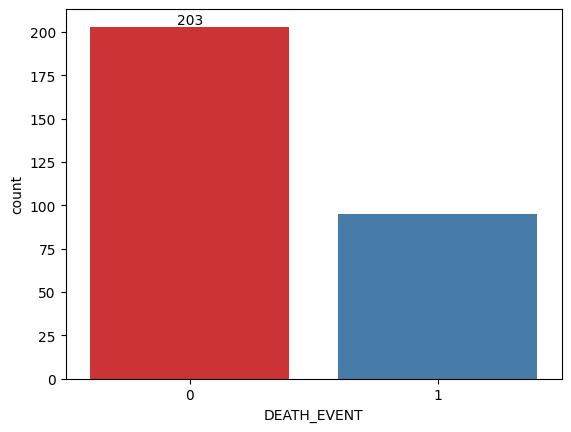

In [14]:
# Evaluating the target and finding out the potential skewness in the data
ax = sns.countplot(x=df["DEATH_EVENT"], palette="Set1")
ax.bar_label(ax.containers[0])

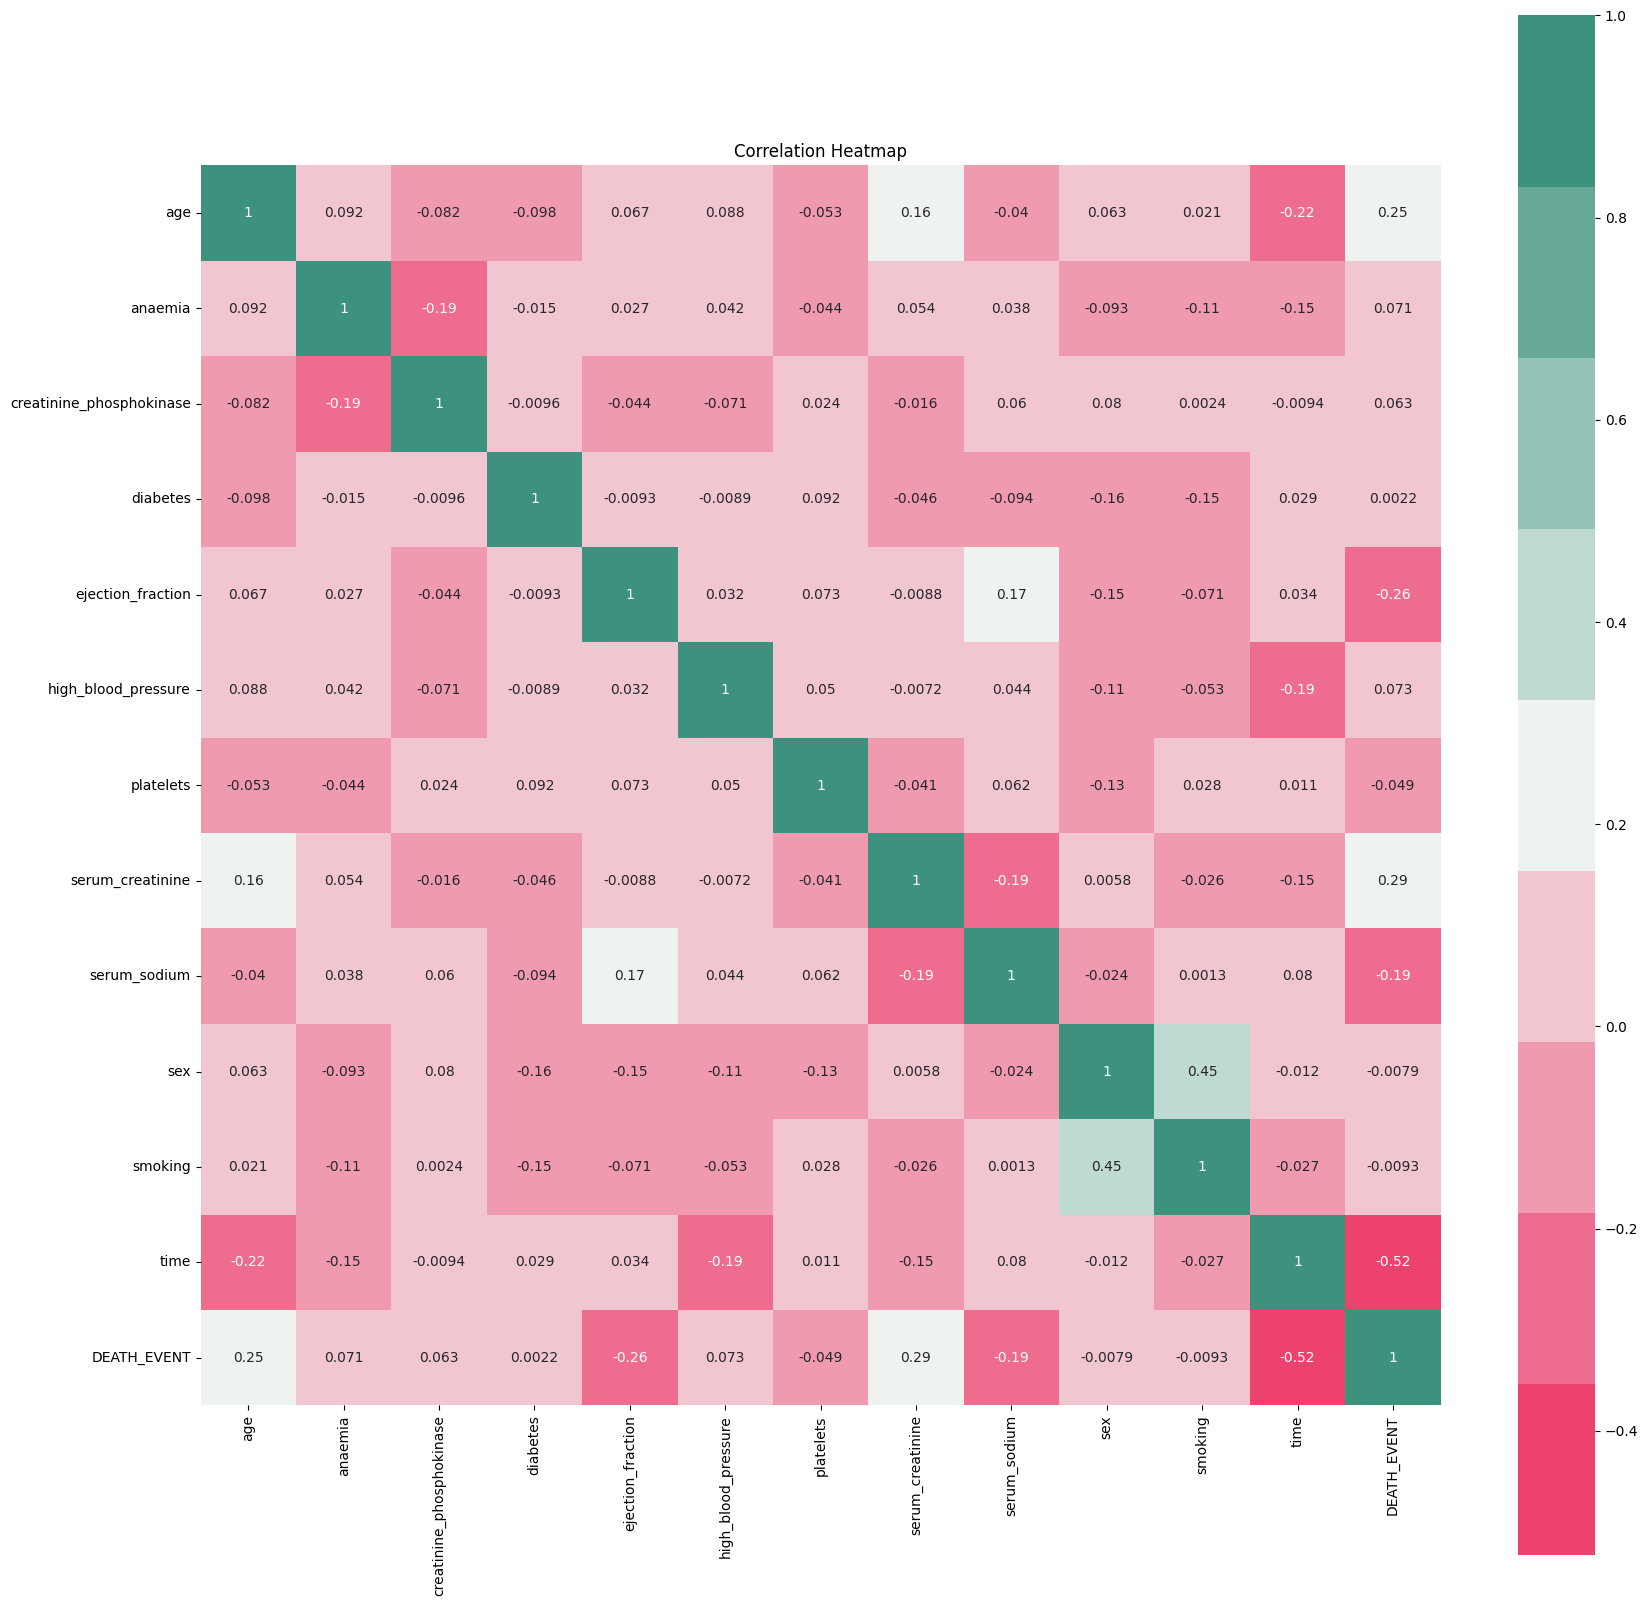

In [17]:
# Doing Bivariate Analysis by examaning a corelation matrix of all the features using heatmap
data_df = df
cmap = sns.diverging_palette(2, 165, s=80, l=55, n=9)
corrmat = data_df.corr(numeric_only=True)
plt.subplots(figsize=(20, 20))
sns.heatmap(corrmat, cmap=cmap, annot=True, square=True)
plt.title("Correlation Heatmap")
plt.show()

Text(0.5, 1.0, 'Distribution Of Age')

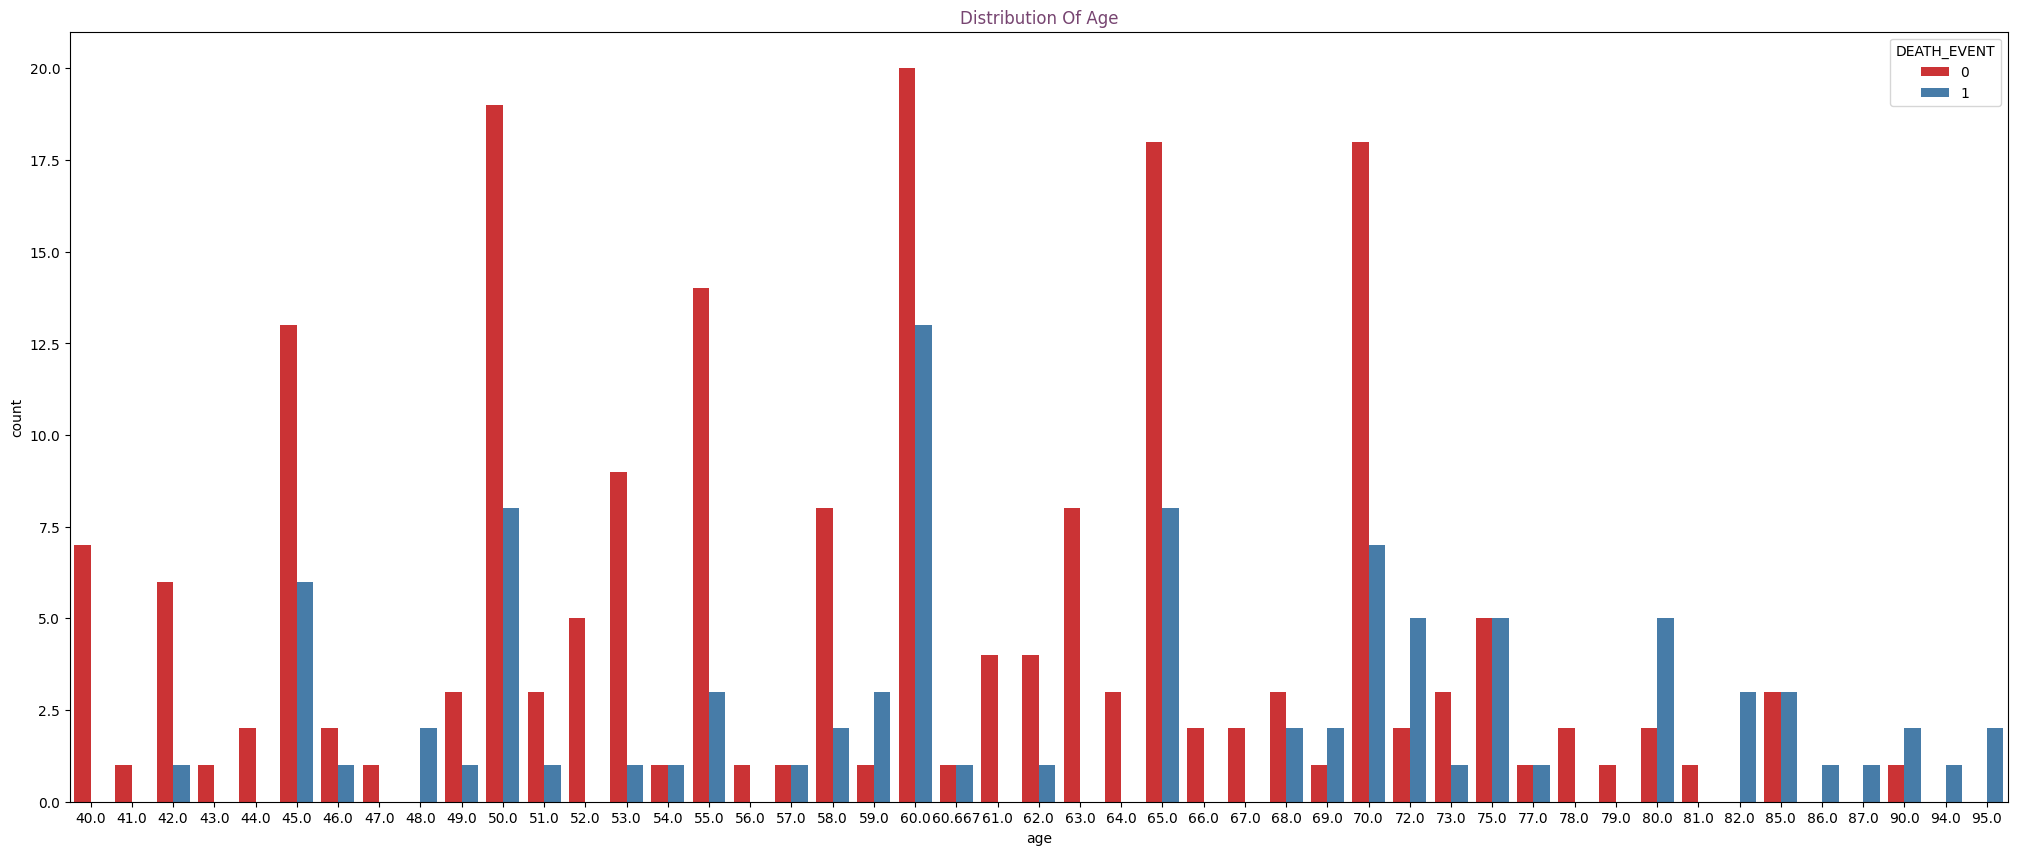

In [18]:
plt.figure(figsize=(25, 10))
Days_of_week = sns.countplot(
    x=data_df["age"], data=data_df, hue="DEATH_EVENT", palette="Set1"
)
Days_of_week.set_title("Distribution Of Age", color="#774571")

/tmp/ipykernel_2135/405163381.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette="Set1")


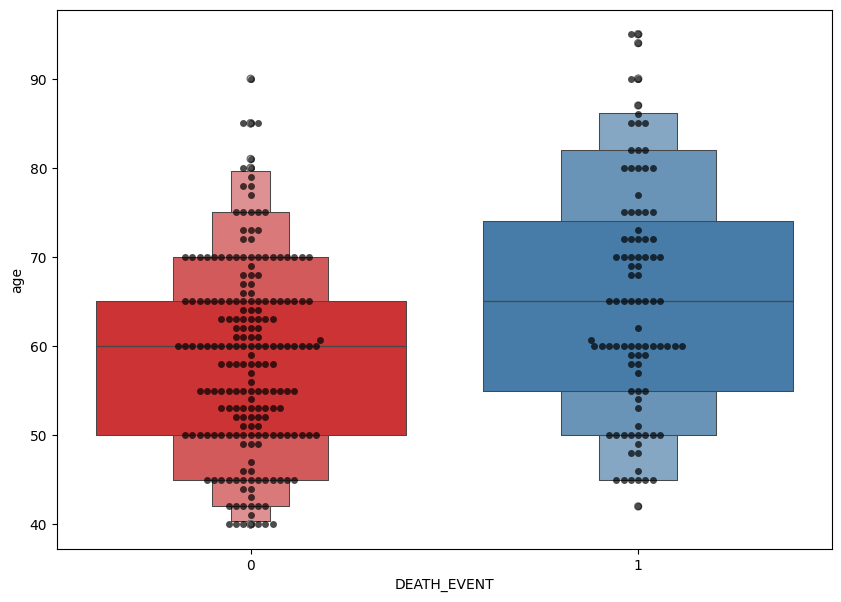

/tmp/ipykernel_2135/405163381.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette="Set1")
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


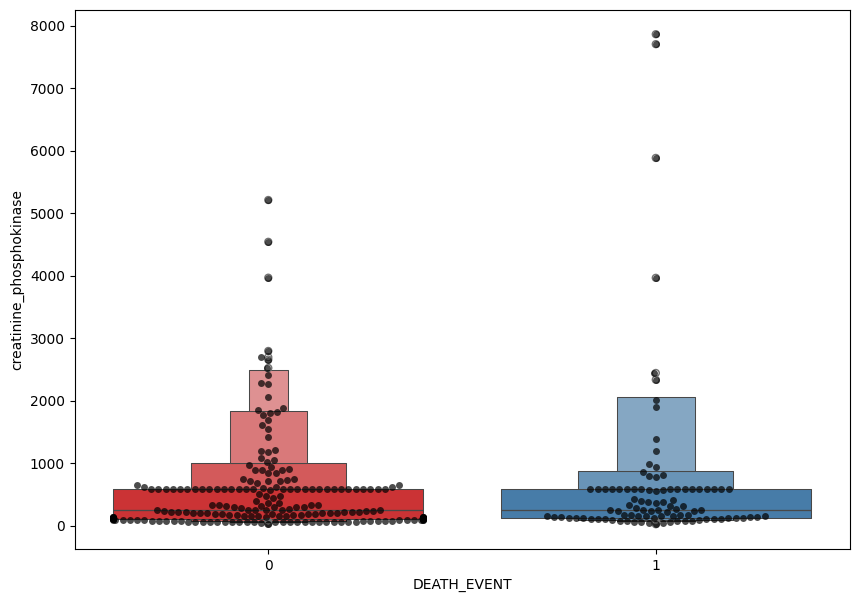

/tmp/ipykernel_2135/405163381.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette="Set1")


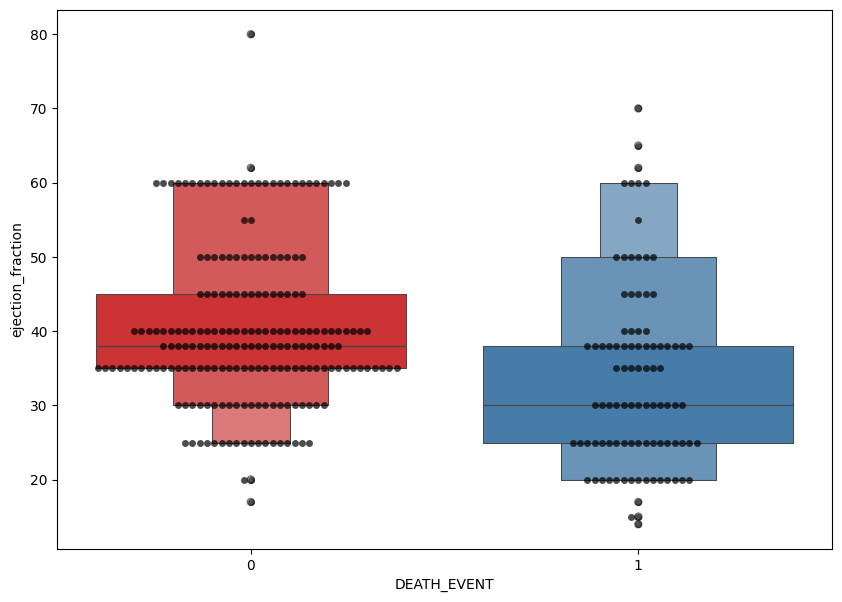

/tmp/ipykernel_2135/405163381.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette="Set1")


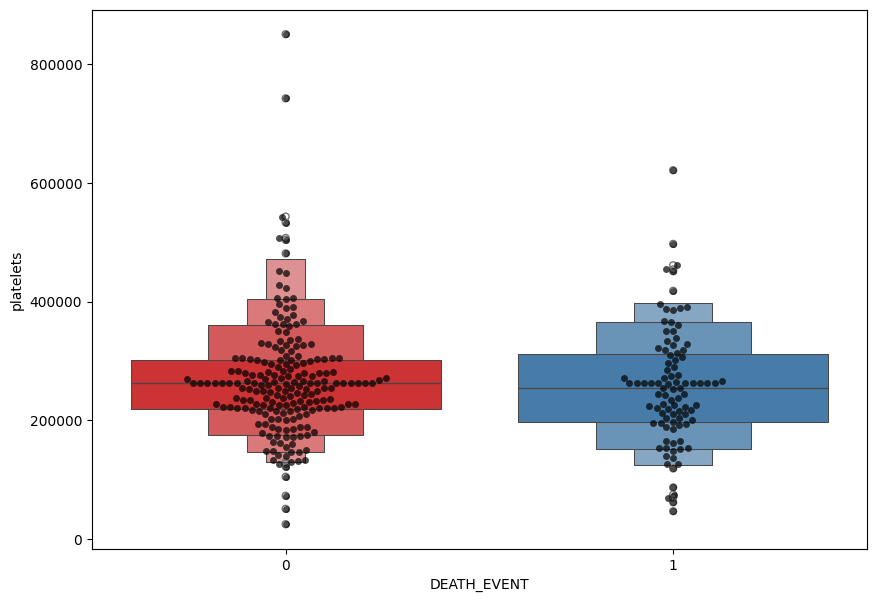

/tmp/ipykernel_2135/405163381.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette="Set1")
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 10.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


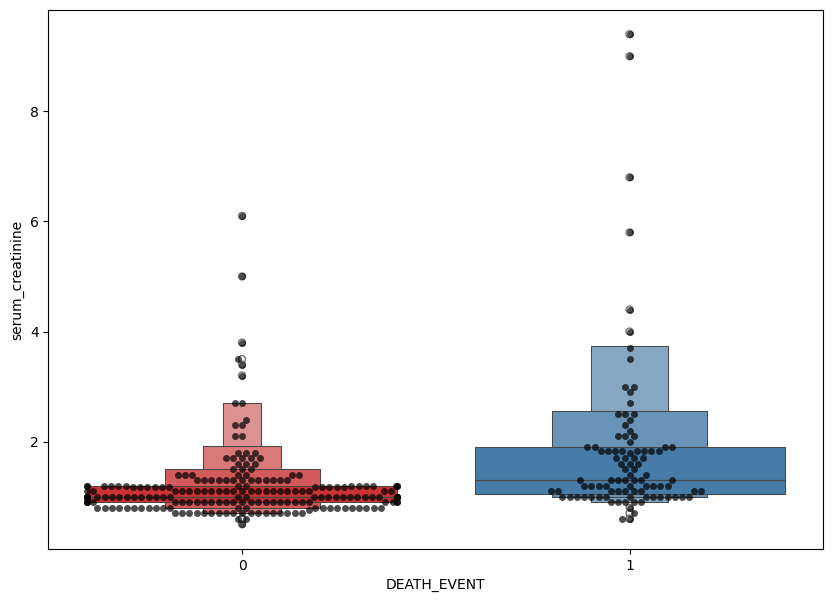

/tmp/ipykernel_2135/405163381.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette="Set1")


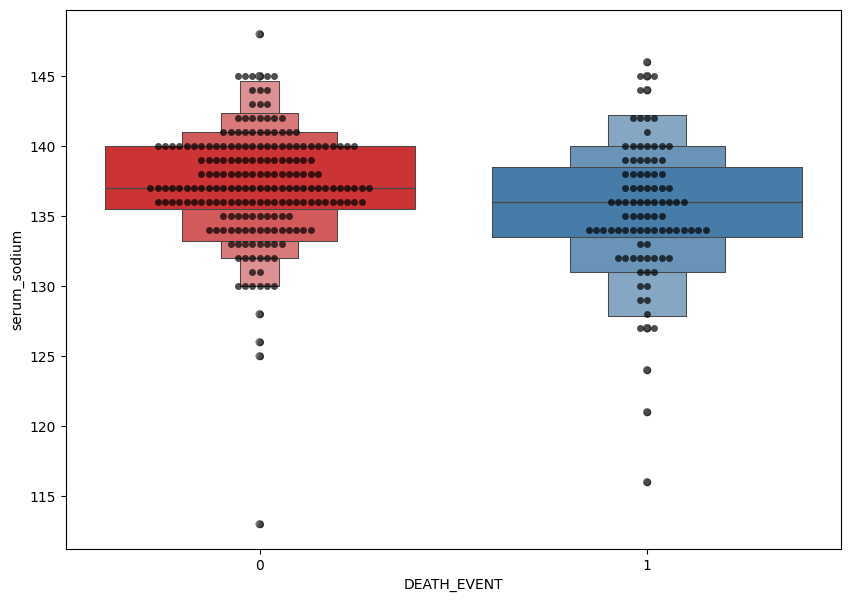

/tmp/ipykernel_2135/405163381.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette="Set1")


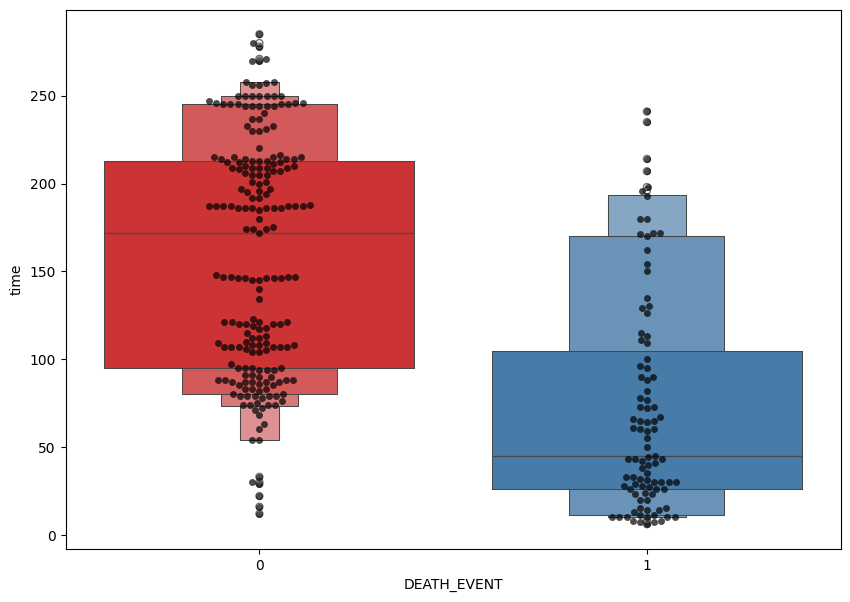

In [19]:
# Checking for potential outliers using the "Boxen and Swarm plots" of non binary features.
feature = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time",
]
for i in feature:
    plt.figure(figsize=(10, 7))
    sns.swarmplot(x=data_df["DEATH_EVENT"], y=data_df[i], color="black", alpha=0.7)
    sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette="Set1")
    plt.show()

                          **: Support Vector Machine**

In [22]:
X = data_df.drop(columns='DEATH_EVENT')
y = data_df['DEATH_EVENT']

# ============================================================
# STEP 3: Train/test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# ============================================================
# STEP 4: Train and evaluate SVM
# ============================================================
print("Evaluation for Support Vector Machine".center(75, "_"))

svm_model = svm.SVC(kernel="linear")
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print("Prediction:    ", svm_pred)
print("_" * 75)
print("Accuracy:" + "\t" + f"{(svm_accuracy * 100)}%")
print("Precision:" + "\t" + f"{(svm_precision * 100)}%")
print("Recall:" + "\t\t" f"{(svm_recall * 100)}%")
print("F1-Score:" + "\t" + f"{(svm_f1 * 100)}%")
print("_" * 75)

X_train shape: (238, 12)
X_test shape: (60, 12)
___________________Evaluation for Support Vector Machine___________________
Prediction:     [0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0
 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0]
___________________________________________________________________________
Accuracy:	80.0%
Precision:	81.81818181818183%
Recall:		47.368421052631575%
F1-Score:	60.0%
___________________________________________________________________________



Logistic Regression

In [23]:
print("Evaluation for Logistic Regression".center(75, "_"))

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print("Prediciton:    ", log_pred)
print("_" * 75)

print("Accuracy:" + "\t" + f"{(log_accuracy * 100)}%")
print("Precision:" + "\t" + f"{(log_precision * 100)}%")
print("Recall:" + "\t\t" f"{(log_recall * 100)}%")
print("F1-Score:" + "\t" + f"{(log_f1 * 100)}%")
print("_" * 75)

_____________________Evaluation for Logistic Regression____________________
Prediciton:     [0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1
 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 0 0]
___________________________________________________________________________
Accuracy:	83.33333333333334%
Precision:	84.61538461538461%
Recall:		57.89473684210527%
F1-Score:	68.75%
___________________________________________________________________________


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
print("Classification Report For Logistic Regression - 'Labels Test' & 'Prediction':")
print("-" * 97)
print(classification_report(y_test, log_pred))

Classification Report For Logistic Regression - 'Labels Test' & 'Prediction':
-------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.95      0.89        41
           1       0.85      0.58      0.69        19

    accuracy                           0.83        60
   macro avg       0.84      0.77      0.79        60
weighted avg       0.83      0.83      0.82        60



   # **Comparsion**

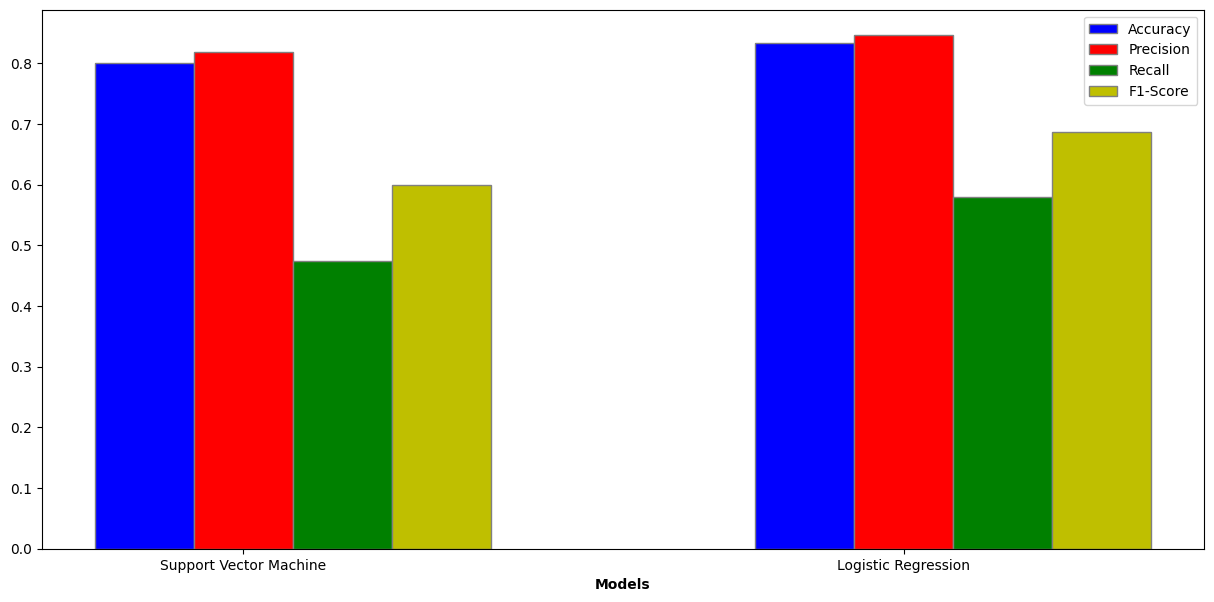

In [25]:
models = ["Support Vector Machine", "Logistic Regression"]
accuracy = [svm_accuracy, log_accuracy]
precision = [svm_precision, log_precision]
recall = [svm_recall, log_recall]
f1 = [svm_f1, log_f1]

barWidth = 0.15

r1 = np.arange(len(accuracy))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
r4 = [x + barWidth for x in r3]

plt.figure(figsize=(15, 7))

plt.bar(r1, accuracy, color="b", width=barWidth, edgecolor="grey", label="Accuracy")
plt.bar(r2, precision, color="r", width=barWidth, edgecolor="grey", label="Precision")
plt.bar(r3, recall, color="g", width=barWidth, edgecolor="grey", label="Recall")
plt.bar(r4, f1, color="y", width=barWidth, edgecolor="grey", label="F1-Score")

plt.xlabel("Models", fontweight="bold")
plt.xticks([r + barWidth for r in range(len(accuracy))], models)

plt.legend()
plt.show()